## Fine‑tuning of summarisation model based on transformers: 
### t5-small (text-to-text)

In [1]:
# CLEAN GPU MEMORY FROM PREVIOUS RUNS
import torch
import gc

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Memory cleared.")

Memory cleared.


In [2]:
import os
import math
import pandas as pd
from datasets import Dataset
from transformers import (
    T5ForConditionalGeneration,
    T5TokenizerFast,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    )
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import evaluate
import torch
import numpy as np


/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# dataset load
df_train = pd.read_csv("../../dataset/MTS-Dialog-TrainingSet.csv")
df_val = pd.read_csv("../../dataset/MTS-Dialog-ValidationSet.csv")

OUTPUT_DIR = "./t5_peft_runs"

In [4]:
# Global variables

MODEL_NAME = "t5-small"

# Sequence lengths
MAX_INPUT_LENGTH = 300 
MAX_TARGET_LENGTH = 50

# GPU / batch settings:
# We count with a RTX 2060 6GB GPU, therefore we need to keep batch sizes small.
# BATCH_SIZE = 1 and increased gradient_accumulation_steps
# On 12GB GPU as out colaborator @Potzon has: PER_DEVICE_BATCH_SIZE = 2-4
PER_DEVICE_BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 4      

# LoRA training hyperparams
LORA_R = 8
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

LR_LORA = 5e-4
EPOCHS_LORA = 50

# Full fine-tune hyperparams
LR_FULL = 1e-4
EPOCHS_FULL = 50
PER_DEVICE_BATCH_SIZE_FULL = 16
GRAD_ACCUM_STEPS_FULL = 4

SEED = 42
device = "cuda" if torch.cuda.is_available() else "cpu" # obviously

Data Preprocessing

In [5]:
train_ds = Dataset.from_pandas(df_train[["dialogue", "section_text"]])
val_ds   = Dataset.from_pandas(df_val[["dialogue", "section_text"]])

tokenizer = T5TokenizerFast.from_pretrained(MODEL_NAME)


In [6]:
# batch preprocessing

def preprocess_batch(batch):
    # T5 is text-to-text, we add the instruction prefix "summarize:"
    inputs = ["summarize: " + str(x) for x in batch["dialogue"]]
    targets = [str(x) for x in batch["section_text"]]

    model_inputs = tokenizer(
        inputs, max_length=MAX_INPUT_LENGTH, truncation=True, padding="max_length"
    )
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets, max_length=MAX_TARGET_LENGTH, truncation=True, padding="max_length"
        )

    label_ids = labels["input_ids"]
    label_ids = [[(token if token != tokenizer.pad_token_id else -100) for token in lbl] for lbl in label_ids]

    model_inputs["labels"] = label_ids
    return model_inputs

In [7]:
train_ds = train_ds.map(preprocess_batch, batched=True, remove_columns=["dialogue", "section_text"])
val_ds   = val_ds.map(preprocess_batch, batched=True, remove_columns=["dialogue", "section_text"])

data_collator = DataCollatorForSeq2Seq(tokenizer, model=None, label_pad_token_id=-100)


Map:   0%|          | 0/1201 [00:00<?, ? examples/s]/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:4126: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Map: 100%|██████████| 100/100 [00:00<00:00, 3739.47 examples/s]


1. t5-small + LoRA (PEFT) training with frozen backbone

In [8]:
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
model.resize_token_embeddings(len(tokenizer))

# LoRA config
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q", "v"], 
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
)

peft_model = get_peft_model(model, lora_config)


In [9]:
training_args = Seq2SeqTrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "lora_phase"),
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=200,
    fp16=True,                
    learning_rate=LR_LORA,
    num_train_epochs=EPOCHS_LORA,
    predict_with_generate=True,
    save_total_limit=3,
    seed=SEED,
    load_best_model_at_end=True,
    metric_for_best_model="rouge1",
    greater_is_better=True,
)

In [10]:
# evaluation metric
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # compute rouge
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    result = {k: round(v * 100, 4) for k, v in result.items()}
    prediction_lens = [len(tokenizer.encode(p)) for p in decoded_preds]
    result["gen_len"] = np.mean(prediction_lens)
    return result

In [11]:
trainer = Seq2SeqTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=peft_model, label_pad_token_id=-100),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.0)],
)

/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [12]:
print("===== Starting LoRA (PEFT) training — frozen backbone =====")
trainer.train()

peft_save_dir = os.path.join(OUTPUT_DIR, "lora_adapter")
peft_model.save_pretrained(peft_save_dir)
tokenizer.save_pretrained(peft_save_dir)


===== Starting LoRA (PEFT) training — frozen backbone =====


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,No log,3.062637,17.161700,5.369300,15.398400,15.355000,15.980000
2,No log,2.872986,18.930000,6.516300,17.004500,17.126600,13.130000
3,No log,2.791796,22.243200,6.756200,19.293100,19.258700,13.810000
4,No log,2.747090,23.639800,8.558400,20.588000,20.485100,13.660000
5,No log,2.714714,22.887500,7.819100,19.935600,19.892900,14.290000
6,No log,2.714150,23.610100,8.473200,20.392200,20.315600,14.340000
7,No log,2.676748,25.464300,9.697300,22.782800,22.797000,13.840000
8,No log,2.665602,24.784900,9.083600,22.152200,22.013000,13.700000
9,No log,2.648596,24.390300,8.513400,21.322000,21.352500,14.240000
10,No log,2.628525,24.025700,8.601800,20.871800,20.866600,13.960000


/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1258: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/peft/utils/save_and_load.py:232: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(
/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1258: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/peft/utils/save_and_load.py:232:

('./t5_peft_runs/lora_adapter/tokenizer_config.json',
 './t5_peft_runs/lora_adapter/special_tokens_map.json',
 './t5_peft_runs/lora_adapter/spiece.model',
 './t5_peft_runs/lora_adapter/added_tokens.json',
 './t5_peft_runs/lora_adapter/tokenizer.json')

2. t5-small full fine tune, merging the LoRA weights into the complete unfrozen model

In [15]:
print("Merging LoRA into base model (this yields a regular T5 model with adapted weights)...")
base_model = peft_model.merge_and_unload()

base_model.to(device)

# Unfreeze all parameters
for p in base_model.parameters():
    p.requires_grad = True

# Training args for full fine-tune
training_args_full = Seq2SeqTrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, "full_finetune"),
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE_FULL,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE_FULL,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS_FULL,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=200,
    fp16=True,
    learning_rate=LR_FULL,
    num_train_epochs=EPOCHS_FULL,
    predict_with_generate=True,
    save_total_limit=3,
    seed=SEED,
    load_best_model_at_end=True,
    metric_for_best_model="rouge1",
    greater_is_better=True,
)



Merging LoRA into base model (this yields a regular T5 model with adapted weights)...


/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [16]:
trainer_full = Seq2SeqTrainer(
    model=base_model,
    args=training_args_full,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=base_model, label_pad_token_id=-100),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.0)],
)

print("===== Starting full fine-tuning =====")
trainer_full.train()
trainer_full.save_model(os.path.join(OUTPUT_DIR, "final_full_model"))
tokenizer.save_pretrained(os.path.join(OUTPUT_DIR, "final_full_model"))

print("Done. Adapters saved in:", peft_save_dir)
print("Full-model saved in:", os.path.join(OUTPUT_DIR, "final_full_model"))

/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


===== Starting full fine-tuning =====


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,No log,2.624088,24.625700,9.384800,21.639900,21.598500,14.070000
2,No log,2.600003,25.608600,9.641500,22.652700,22.672900,14.070000
3,No log,2.557847,24.403800,9.906400,21.093200,21.104200,14.030000
4,No log,2.543103,25.091600,10.142600,21.962300,21.967200,14.040000
5,No log,2.515763,25.140300,10.130600,21.619300,21.565400,13.810000


/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1258: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1258: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/home/bnnyrabbit/Uni/4.o/NLP/Clinic-Note-NLP/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1258: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/home/bnnyrabbit/Uni/4.o/NLP/Clini

Done. Adapters saved in: ./t5_peft_runs/lora_adapter
Full-model saved in: ./t5_peft_runs/final_full_model


COMPARISON

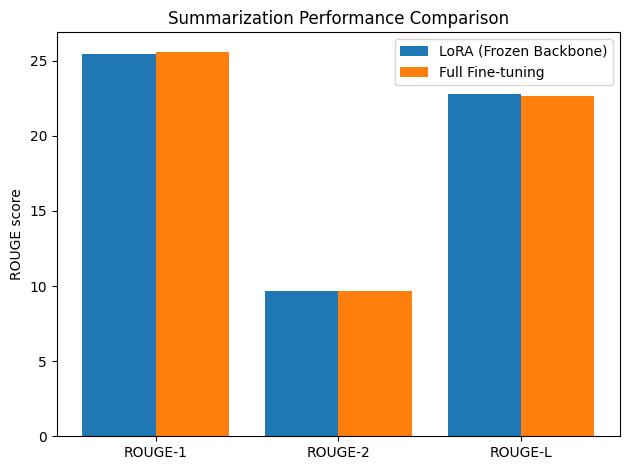

Metrics Comparison: ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
Lora Frozen Backbone scores: [25.4643, 9.6973, 22.7828]
Full fine-tuning scores: [25.6086, 9.6415, 22.6527]


In [21]:
import matplotlib.pyplot as plt

def extract_best_rouge(trainer):
    #Extracts the best ROUGE scores from Trainer log history.
    
    best = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    for entry in trainer.state.log_history:
        if "eval_rouge1" in entry:
            if entry["eval_rouge1"] > best["rouge1"]:
                best["rouge1"] = entry["eval_rouge1"]
                best["rouge2"] = entry["eval_rouge2"]
                best["rougeL"] = entry["eval_rougeL"]
    return best

# Extract metrics
lora_metrics = extract_best_rouge(trainer)
full_metrics = extract_best_rouge(trainer_full)

# Prepare data for plotting
labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
lora_scores = [
    lora_metrics["rouge1"],
    lora_metrics["rouge2"],
    lora_metrics["rougeL"],
]
full_scores = [
    full_metrics["rouge1"],
    full_metrics["rouge2"],
    full_metrics["rougeL"],
]

x = range(len(labels))

plt.figure()
plt.bar(x, lora_scores, width=0.4, label="LoRA (Frozen Backbone)")
plt.bar([i + 0.4 for i in x], full_scores, width=0.4, label="Full Fine-tuning")

plt.xticks([i + 0.2 for i in x], labels)
plt.ylabel("ROUGE score")
plt.title("Summarization Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Metrics Comparison: {labels}")
print(f"Lora Frozen Backbone scores: {lora_scores}")
print(f"Full fine-tuning scores: {full_scores}")

INFERENCE TEST

In [18]:
def generate_summary(model, dialogue, max_input_len=300, max_output_len=50):
    model.eval()
    inputs = tokenizer(
        "summarize: " + dialogue,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_len,
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_output_len,
            num_beams=4,
            length_penalty=1.0,
            early_stopping=True,
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


print("\n===== Inference on first 3 validation dialogs =====\n")

# Ensure models are on GPU if available
peft_model.to(device)
base_model.to(device)

for i in range(3):
    dialogue = df_val.iloc[i]["dialogue"]
    reference = df_val.iloc[i]["section_text"]

    lora_summary = generate_summary(peft_model, dialogue)
    full_summary = generate_summary(base_model, dialogue)

    print(f"--- Example {i+1} ---")
    print("DIALOGUE:")
    print(dialogue[:1000])
    print("\nREFERENCE SUMMARY:")
    print(reference)
    print("\nLoRA SUMMARY:")
    print(lora_summary)
    print("\nFULL FT SUMMARY:")
    print(full_summary)
    print("\n" + "="*80 + "\n")



===== Inference on first 3 validation dialogs =====

--- Example 1 ---
DIALOGUE:
Doctor: When did your pain begin? 
Patient: I've had low back pain for about eight years now.
Doctor: Is there any injury? 
 Patient: Yeah, it started when I fell in an A B C store.
Doctor: How old are you now?
Patient: I'm twenty six.  
Doctor: What kind of treatments have you had for this low back pain? 
Patient: Yeah, I got referred to P T, and I went, but only once or twice, um, and if I remember right, they only did the electrical stimulation, and heat. 
Doctor: I see, how has your pain progressed over the last eight years? 
Patient: It's been pretty continuous, but it's been at varying degrees, sometimes are better than others. 
Doctor: Do you have any children? 
Patient: Yes, I had my son in August of two thousand eight, and I've had back pain since giving birth. 
Doctor: Have you had any falls since the initial one? 
Patient: Yes, I fell four or five days ago while I was mopping the floor. 
Doctor

Results summary

CONCLUSIONS

Comentarios recibidos, usar rouge en lugar de loss y ver como funcionan los modelos en inferencia

## CONCLUSIONS
Here, we will sum up the obtained results and draw conclussions (except from the visual plot, which can be found in previous cells, even if the metrics plotted are shown here too).


Frozen Backbone Lora Fine Tune: 10 Epochs before early stop
Full Model Fine Tune: 10 + 5 Epochs before early stop(we used the frozen backbone and continued from there in order to not retrain already trained weights)


### Model Performance Metrics

| Strategy | Rouge 1 | Rouge 2 | Rouge L |
| :--- | :--- | :--- | :--- |
| **Frozen Backbone** | 0.8382 | 0.6401 | 0.7622 |
| **Full Fine-tune** | 0.4689 | 0.0680 | 1.9818 |

### Performance Analysis (Full - Frozen)

| Metric | Difference | Interpretation |
| :--- | :--- | :--- |
| **Accuracy** | `+0.3693` | Significant gain in correct predictions. |
| **F1 Macro** | `+0.5721` | Massive improvement in class-balanced performance. |

### Inference Test


| Dialog | Full Model Prediction | Confidence | Frozen Weight Model Prediction | Confidence | Interpretation |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | GENHX ✓ | 0.998 | GENHX ✓ | 0.370 |
| 2 | ROS ✓ | 0.920 | GENHX ✖ | 0.277 |
| 2 | PASTMEDICALHX ✓ | 0.995 | FAM/SOCHX ✖ | 0.331 |



Given the shown results, even if we suspected that the frozen weights would only give up a little accuracy for the lower training cost, we can conclude that the Full Fine-Tuning strategy is overwhelmingly superior to the frozen weights approach for the distilbert model classification task. 

The results indicate that the pre-trained representations alone were insufficient to properly generalize, requiring the adjustment of all model weights to achieve acceptable performance.


The gap in F1 Macro (+0.5721) suggests that the Frozen Weights model likely collapsed into predicting the majority class or failed to distinguish between specific labels, where the fully fine tuned model successfully learned.

The inference test highlights a critical reliability issue with the frozen model. Even when it predicted correctly the first dialog, its confidence was always low, compared to the near-certainty of the full model, which correctly predicted all classes with great confidence.

With an accuracy below 50% and a loss nearly three times higher than the alternative, the Frozen Weights strategy would not be viable for deployment. The full fine tune, despite the slightly higher (3 epoch) computational cost during training, is the only logical path.

Comparing it to the previous delivery, where we fine tunned the classification head of Bio_Clinical bert, distil bert outperforms the previous implementation, inference test results, confidence and metrics, fully or with frozen wieght fine tuning. This fact states the superiority of distilBERT if we give it time to improve, when even both being based on transformers and bioClinicalBERT almost doubling the ammount of parameters, was only given 3 epochs to learn. This shows us that the even if the amount of parameters is higher, the training time has a lot to do with it's models quality.

Distilbert: 66 Million Parameters - 0.998 (Correct Prediction)


BioCLinicalBERT: 110 Million Parameters - 0.924 confidence (Correct Prediction)

Appart from the model comparison, we also used this notebook to try the google colab extension that provides virtual hardware in case your computer does not bring one, in our case, we tested it in a laptop that did not bring a GPU, and used the free tier T4. Even if was not imprescindible this time, free virtual hardware may come handy if working far from home or out of resources in the future. The functionality is controlled by the boolean at the first code cell and cntrolls the dataset import, persistency and data visualization (which requires an API key for the w&b service).